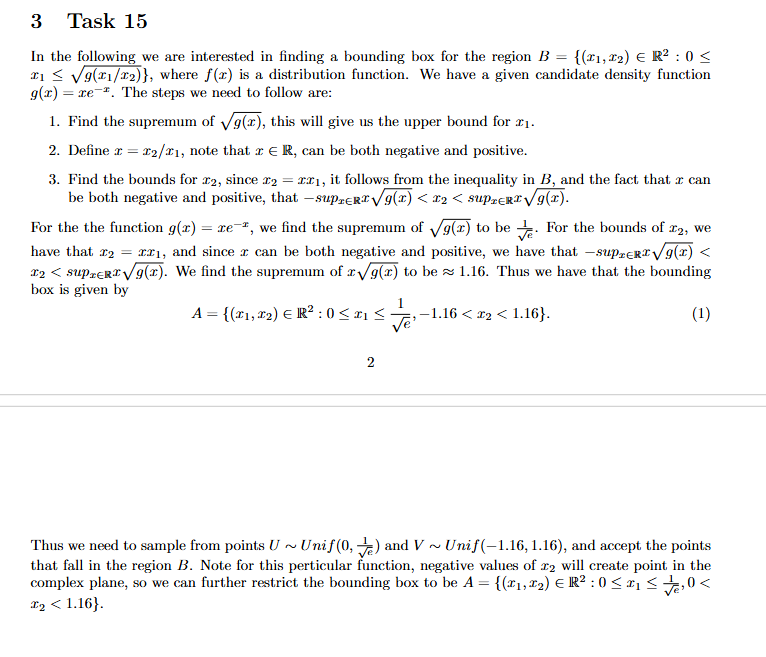

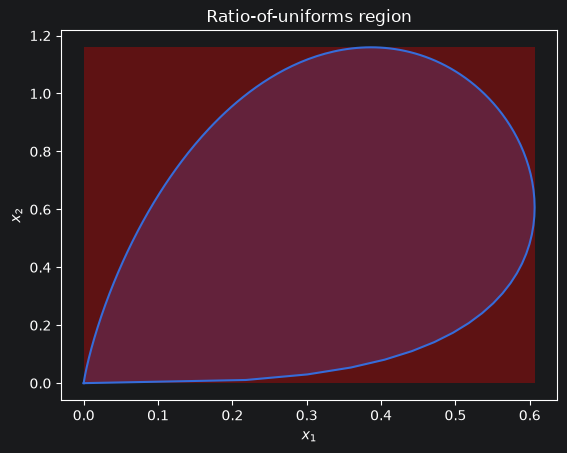

In [53]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
# Candidate Density
def g(x):
    return x * np.exp(-x)

# x values
x = np.linspace(0, 50, 1000)

# Boundary of the RoU region
x1 = np.sqrt(g(x))
x2 = x * np.sqrt(g(x))
fig, ax = plt.subplots()
plt.plot(x1, x2)
# Fill the region underneath/inside it
plt.fill_between(x1, x2, alpha=0.3)
rect = Rectangle((0, 0), 1/np.sqrt(np.e), 1.16, facecolor="red", alpha=0.3)
ax.add_patch(rect)
plt.xlabel(r"$x_1$")
plt.ylabel(r"$x_2$")
plt.title("Ratio-of-uniforms region")

plt.show()

We can now sample from $f(x) = \frac{1}{C}g(x) $

Proportion of sample in B is 0.707


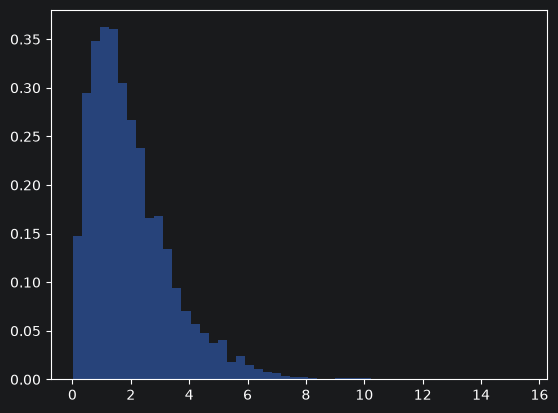

In [54]:
N = 10000
U = np.random.uniform(0, 1/np.sqrt(np.e), N)
V = np.random.uniform(0, 1.16, N)
def ratio_of_uniforms(func, U, V):
    mask = (0 < U) & (U < np.sqrt(func(V/U)))
    sample = V / U
    sample = sample[mask]
    return sample, mask
s, m = ratio_of_uniforms(g, U, V)

print(f"Proportion of sample in B is {np.sum(m) / N}")
plt.hist(s, bins=50, density=True, alpha=0.5, label="Ratio of uniforms")
plt.show()

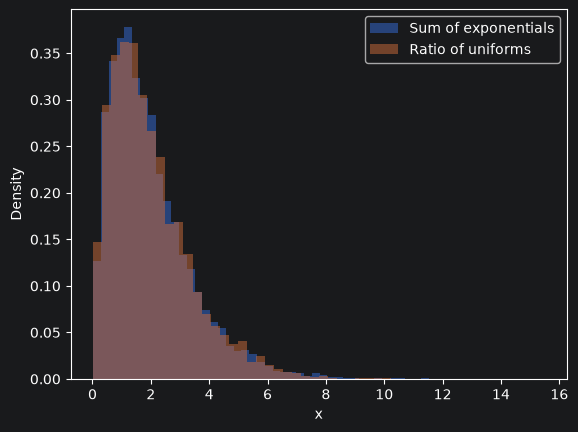

In [55]:
X1 = np.random.exponential(1, N)
X2 = np.random.exponential(1, N)
X = X1 + X2
plt.hist(X, bins=50, density=True, alpha=0.5, label="Sum of exponentials")
plt.hist(s, bins=50, density=True, alpha=0.5, label="Ratio of uniforms")

plt.xlabel("x")
plt.ylabel("Density")
plt.legend()
plt.show()